# Mudcard
- **how do we simulate deploying our model in our final project to check the effect of resampling?**
    - when the model is deployed, the class balances of the incoming data is the same as the original data before rebalancing
    - once you have a confusion matrix on the balanced dataset, write down the terms as rates with respect to the condition negative and positive samples
    - you can then calculate what the evaluatino metric will really be when the model is deployed
    - but it's even better if you don't resample, just use the data as is and use models with class_weight
- **how do we remember all these parameters? practice a lot?**
    - yeah, that's the best way to learn
    - once you work through a couple of ML problems yourself, you'll get the hang of it
- **"What is the difference between the 'weights' parameter in KNeighborsClassifier and 'class_weight' used in other algorithms? Wouldn't this be analogous to class_weight?**
    - Nope
    - You'll see it in PS8. I can't discuss it further because that would give away the solution to one of the problems.
- **I'm confused about when it would ever be 'worth it' to augment/resample the data, given the pitfalls that can arise when using the model on new data**
    - It's fine to resample if you use a metric that won't be impacted by it like recall
    - so before you resample, figure out if your metric is impacted by it

# Missing values, part 1
### By the end of this lecture, you will be able to
- evaluate simple approaches to handle missing values: drop rows and columns
- handle missing values in categorical and ordinal features in preprocessing
- apply imputation techniques on continuous features and evaluate drawbacks


### <font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- **evaluate simple approaches to handle missing values: drop rows and columns**
- <font color='LIGHTGRAY'>handle missing values in categorical and ordinal features in preprocessing</font>
- <font color='LIGHTGRAY'>apply imputation techniques on continuous features and evaluate drawbacks</font>


## Dataset
- kaggle house price dataset
- check out the train.csv and the dataset description in the `data` folder (`data/data_description.txt`)!

In [1]:
# read the data
import pandas as pd
import numpy  as np
from sklearn.model_selection import train_test_split

# Let's load the data
df = pd.read_csv('../data/train.csv')
# drop the ID
df.drop(columns=['Id'],inplace=True)

# the target variable
y = df['SalePrice']
df.drop(columns=['SalePrice'],inplace=True)
# the unprocessed feature matrix
X = df
print(X.shape)
# the feature names
ftrs = df.columns
print(df.head())

(1460, 79)
   MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0          60       RL         65.0     8450   Pave   NaN      Reg   
1          20       RL         80.0     9600   Pave   NaN      Reg   
2          60       RL         68.0    11250   Pave   NaN      IR1   
3          70       RL         60.0     9550   Pave   NaN      IR1   
4          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC Fence  \
0         Lvl    AllPub    Inside  ...           0        0    NaN   NaN   
1         Lvl    AllPub       FR2  ...           0        0    NaN   NaN   
2         Lvl    AllPub    Inside  ...           0        0    NaN   NaN   
3         Lvl    AllPub    Corner  ...           0        0    NaN   NaN   
4         Lvl    AllPub       FR2  ...           0        0    NaN   NaN   

  MiscFeature MiscVal  MoSold  YrSold  SaleType  SaleCondition  
0         NaN       0       2    2008        W

In [2]:
print('data dimensions:',df.shape)
perc_missing_per_ftr = df.isnull().sum(axis=0)/df.shape[0]
print('fraction of missing values in features:')
print(perc_missing_per_ftr[perc_missing_per_ftr > 0])
print('data types of the features with missing values:')
print(df[perc_missing_per_ftr[perc_missing_per_ftr > 0].index].dtypes)
frac_missing = sum(df.isnull().sum(axis=1)!=0)/df.shape[0]
print('fraction of points with missing values:',frac_missing)

data dimensions: (1460, 79)
fraction of missing values in features:
LotFrontage     0.177397
Alley           0.937671
MasVnrType      0.597260
MasVnrArea      0.005479
BsmtQual        0.025342
BsmtCond        0.025342
BsmtExposure    0.026027
BsmtFinType1    0.025342
BsmtFinType2    0.026027
Electrical      0.000685
FireplaceQu     0.472603
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
PoolQC          0.995205
Fence           0.807534
MiscFeature     0.963014
dtype: float64
data types of the features with missing values:
LotFrontage     float64
Alley            object
MasVnrType       object
MasVnrArea      float64
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Electrical       object
FireplaceQu      object
GarageType       object
GarageYrBlt     float64
GarageFinish     object
GarageQual       object
GarageCond       object
PoolQC    

## Exclude points or features with missing values
- easy to do with pandas
- if missing values were encountered during data collection, it is likely missing values will occur during deployment too
    - what will you do during deployment?
    - by dropping columns/rows, you basically ignore the missing values
    - is it OK to not predict for a datapoint with missing values when the model is deployed?
        - in finance and medical problems, this is not a luxury you will have
- it's OK to temporarily drop a small fraction of rows/columns to quickly train a model and see if the project is feasible
- but if the project makes it to deployment, you will not be able to ignore the issue

##### Drop points or features with missing values
- not OK for the house price dataset because all points contain some NaNs.

In [3]:
print(df.shape)
# by default, rows/points are dropped
df_r = df.dropna()
print(df_r.shape)
# drop features with missing values
df_c = df.dropna(axis=1)
print(df_c.shape)


(1460, 79)
(0, 79)
(1460, 60)


### <font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- <font color='LIGHTGRAY'>evaluate simple approaches to handle missing values: drop rows and columns</font>
- **handle missing values in categorical and ordinal features in preprocessing**
- <font color='LIGHTGRAY'>apply imputation techniques on continuous features and evaluate drawbacks</font>


## Categorical or ordinal features: treat missing values as another category

- the BEST thing you can do!
- already covered in the preprocessing lecture (one hot encoding)
- example: missing values in gender
    - if survey only has options for male/female, missing values are likely because those people are outside the gender binary
    - it is a bad idea to impute (try to guess male or female and thus boxing them into the binary)
- example: native country in the adult data
    - missing data are represented as ` ?`
    - a one-hot encoded feature was assigned to the missing category


In [4]:
# read the data
import pandas as pd
import numpy  as np
from sklearn.model_selection import train_test_split

# Let's load the data
df = pd.read_csv('../data/train.csv')
# drop the ID
df.drop(columns=['Id'],inplace=True)

# the target variable
y = df['SalePrice']
df.drop(columns=['SalePrice'],inplace=True)
# the unprocessed feature matrix
X = df.values
print(X.shape)
# the feature names
ftrs = df.columns

(1460, 79)


In [5]:
random_state = 42

# let's split to train, CV, and test
X_train, X_other, y_train, y_other = train_test_split(df, y, train_size=0.6, random_state=random_state)
X_CV, X_test, y_CV, y_test = train_test_split(X_other, y_other, test_size=0.5, random_state=random_state)

print(X_train.shape)
print(X_CV.shape)
print(X_test.shape)

(876, 79)
(292, 79)
(292, 79)


In [6]:
# collect the various features
cat_ftrs = ['MSZoning','Street','Alley','LandContour','LotConfig','Neighborhood','Condition1','Condition2',\
            'BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation',\
           'Heating','CentralAir','Electrical','GarageType','PavedDrive','MiscFeature','SaleType','SaleCondition']
ordinal_ftrs = ['LotShape','Utilities','LandSlope','ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure',\
               'BsmtFinType1','BsmtFinType2','HeatingQC','KitchenQual','Functional','FireplaceQu','GarageFinish',\
               'GarageQual','GarageCond','PoolQC','Fence']
ordinal_cats = [['Reg','IR1','IR2','IR3'],['AllPub','NoSewr','NoSeWa','ELO'],['Gtl','Mod','Sev'],\
               ['Po','Fa','TA','Gd','Ex'],['Po','Fa','TA','Gd','Ex'],['NA','Po','Fa','TA','Gd','Ex'],\
               ['NA','Po','Fa','TA','Gd','Ex'],['NA','No','Mn','Av','Gd'],['NA','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],\
               ['NA','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],['Po','Fa','TA','Gd','Ex'],['Po','Fa','TA','Gd','Ex'],\
               ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ'],['NA','Po','Fa','TA','Gd','Ex'],\
               ['NA','Unf','RFn','Fin'],['NA','Po','Fa','TA','Gd','Ex'],['NA','Po','Fa','TA','Gd','Ex'],
               ['NA','Fa','TA','Gd','Ex'],['NA','MnWw','GdWo','MnPrv','GdPrv']]
num_ftrs = ['MSSubClass','LotFrontage','LotArea','OverallQual','OverallCond','YearBuilt','YearRemodAdd',\
             'MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF',\
             'LowQualFinSF','GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr',\
             'KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageYrBlt','GarageCars','GarageArea','WoodDeckSF',\
             'OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal','MoSold','YrSold']

In [7]:
# preprocess with pipeline and columntransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

random_state = 42

# one-hot encoder
# We need to replace the NaN with a string first!
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])

# ordinal encoder
# We need to replace the NaN with a string first!
ordinal_transformer = Pipeline(steps=[
    ('imputer2', SimpleImputer(strategy='constant',fill_value='NA')),
    ('ordinal', OrdinalEncoder(categories = ordinal_cats))])

# standard scaler
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# collect the transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_ftrs),
        ('cat', categorical_transformer, cat_ftrs),
        ('ord', ordinal_transformer, ordinal_ftrs)])

In [8]:
# fit_transform the training set
X_prep = preprocessor.fit_transform(X_train)
# the feature names after fit
feature_names = preprocessor.get_feature_names_out()

# you can convert the numpy array back to a data frame with the feature names if you want
df_train = pd.DataFrame(data=X_prep,columns=feature_names)
print(df_train.shape)

# transform the CV
df_CV = preprocessor.transform(X_CV)
df_CV = pd.DataFrame(data=df_CV,columns = feature_names)
print(df_CV.shape)

# transform the test
df_test = preprocessor.transform(X_test)
df_test = pd.DataFrame(data=df_test,columns = feature_names)
print(df_test.shape)
print(feature_names)

(876, 222)
(292, 222)
(292, 222)
['num__MSSubClass' 'num__LotFrontage' 'num__LotArea' 'num__OverallQual'
 'num__OverallCond' 'num__YearBuilt' 'num__YearRemodAdd' 'num__MasVnrArea'
 'num__BsmtFinSF1' 'num__BsmtFinSF2' 'num__BsmtUnfSF' 'num__TotalBsmtSF'
 'num__1stFlrSF' 'num__2ndFlrSF' 'num__LowQualFinSF' 'num__GrLivArea'
 'num__BsmtFullBath' 'num__BsmtHalfBath' 'num__FullBath' 'num__HalfBath'
 'num__BedroomAbvGr' 'num__KitchenAbvGr' 'num__TotRmsAbvGrd'
 'num__Fireplaces' 'num__GarageYrBlt' 'num__GarageCars' 'num__GarageArea'
 'num__WoodDeckSF' 'num__OpenPorchSF' 'num__EnclosedPorch'
 'num__3SsnPorch' 'num__ScreenPorch' 'num__PoolArea' 'num__MiscVal'
 'num__MoSold' 'num__YrSold' 'cat__MSZoning_C (all)' 'cat__MSZoning_FV'
 'cat__MSZoning_RH' 'cat__MSZoning_RL' 'cat__MSZoning_RM'
 'cat__Street_Grvl' 'cat__Street_Pave' 'cat__Alley_Grvl' 'cat__Alley_Pave'
 'cat__Alley_missing' 'cat__LandContour_Bnk' 'cat__LandContour_HLS'
 'cat__LandContour_Low' 'cat__LandContour_Lvl' 'cat__LotConfig_Corner

In [9]:
print('data dimensions:',df_train.shape)
perc_missing_per_ftr = df_train.isnull().sum(axis=0)/df_train.shape[0]
print('fraction of missing values in features:')
print(perc_missing_per_ftr[perc_missing_per_ftr > 0])
print('data types of the features with missing values:')
print(df_train[perc_missing_per_ftr[perc_missing_per_ftr > 0].index].dtypes)
frac_missing = sum(df_train.isnull().sum(axis=1)!=0)/df_train.shape[0]
print('fraction of points with missing values:',frac_missing)

data dimensions: (876, 222)
fraction of missing values in features:
num__LotFrontage    0.190639
num__MasVnrArea     0.002283
num__GarageYrBlt    0.052511
dtype: float64
data types of the features with missing values:
num__LotFrontage    float64
num__MasVnrArea     float64
num__GarageYrBlt    float64
dtype: object
fraction of points with missing values: 0.23972602739726026


## Quiz 1
The gender feature below contains missing values. Please explain how you would encode it and would be the output of the encoder. Do not write code. The goal of this quiz is to test your conceptual understanding so write text and the output array.

gender = ['Male', 'Female', 'Male', NaN, NaN, 'Female']


### <font color='LIGHTGRAY'>By the end of this lecture, you will be able to</font>
- <font color='LIGHTGRAY'>evaluate simple approaches to handle missing values: drop rows and columns</font>
- <font color='LIGHTGRAY'>handle missing values in categorical and ordinal features in preprocessing</font>
- **apply imputation techniques on continuous features and evaluate drawbacks**


## Continuous feature: sklearn's SimpleImputer

- Imputation means you infer the missing values from the known part of the data
- sklearn's SimpleImputer can do mean and median imputation
    - the missing values are replaced with the mean or median of the non-missing values
- A BAD IDEA!
   - mean or median imputation changes the statistical properties of the feature
   - specifically, it decreases the variance

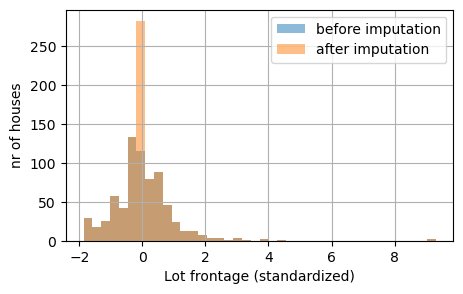

std before imputation: 1.0
std after imputation: 0.8996447802291788


In [10]:
import matplotlib.pyplot as plt

si = SimpleImputer(strategy='mean')
X_lot = si.fit_transform(df_train[['num__LotFrontage']])

plt.figure(figsize=(5,3))
df_train['num__LotFrontage'].hist(bins=40,label = 'before imputation',alpha=0.5)
plt.hist(X_lot,bins=40,label='after imputation',alpha=0.5)
plt.xlabel('Lot frontage (standardized)')
plt.ylabel('nr of houses')
plt.legend()
plt.show()

print('std before imputation:',np.std(df_train['num__LotFrontage']))
print('std after imputation:',np.std(X_lot))

## Multivariate Imputation

- models each feature with missing values as a function of other features, and uses that estimate for imputation
   - at each step, a feature is designated as target variable and the other feature columns are treated as feature matrix X
   - a regressor is trained on (X, y) for known y
   - then, the regressor is used to predict the missing values of y
- in the ML pipeline:
   - create n imputed datasets
   - run all of them through the ML pipeline
   - generate n test scores
   - the uncertainty in the test scores is due to the uncertainty in imputation
- paper [here](https://www.jstatsoft.org/article/view/v045i03)

### sklearn's IterativeImputer
- reproducability is important!
- we can't measure how accurate the imputed values are
- but we can measure how much uncertainty they add to the model's predictions!
    - use a non-deterministic estimator like a decision tree
    - loop through 3-10 random states and create 3-10 imputed datasets
    - measure the mean and std of the test score
    - uncertainty might be confounded with other sources of uncertainty due to random splitting and non-deterministic ML models

In [29]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

print(df_train[['num__LotFrontage','num__MasVnrArea','num__GarageYrBlt']].head())

imputer = IterativeImputer(estimator = RandomForestRegressor(n_estimators=1, random_state=42))
X_impute = imputer.fit_transform(df_train)
df_train_imp = pd.DataFrame(data=X_impute, columns = df_train.columns)

print(df_train_imp[['num__LotFrontage','num__MasVnrArea','num__GarageYrBlt']].head())

df_CV_imp = pd.DataFrame(data=imputer.transform(df_CV), columns = df_train.columns)
df_test_imp = pd.DataFrame(data=imputer.transform(df_test), columns = df_train.columns)

   num__LotFrontage  num__MasVnrArea  num__GarageYrBlt
0         -0.372911        -0.606613         -2.126354
1         -0.678966        -0.606613         -1.927257
2               NaN         0.706580          0.063711
3          0.200943        -0.606613          0.422085
4         -0.066855        -0.606613          1.138834
   num__LotFrontage  num__MasVnrArea  num__GarageYrBlt
0         -0.372911        -0.606613         -2.126354
1         -0.678966        -0.606613         -1.927257
2          0.353971         0.706580          0.063711
3          0.200943        -0.606613          0.422085
4         -0.066855        -0.606613          1.138834


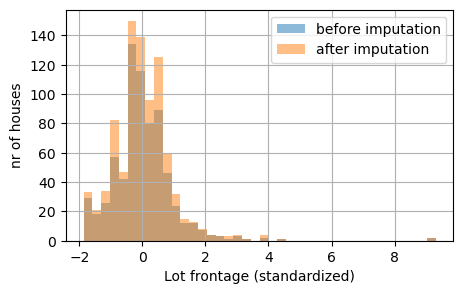

std before imputation: 1.0
std after imputation: 0.9868415653482085


In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
df_train['num__LotFrontage'].hist(bins=40,label = 'before imputation',alpha=0.5)
plt.hist(df_train_imp['num__LotFrontage'],bins=40,label='after imputation',alpha=0.5)
plt.xlabel('Lot frontage (standardized)')
plt.ylabel('nr of houses')
plt.legend()
plt.show()

print('std before imputation:',np.std(df_train['num__LotFrontage']))
print('std after imputation:',np.std(df_train_imp['num__LotFrontage']))

## Does it make sense to impute?
- GarageYearBuilt should definitely not be imputed because a missing value indicates no garage on the property
- What does it mean to make up a year of construction for a garage that does not exist?

# Mudcard